# 2. Modal semangkuk: berapa sih biaya bahan mie ayam?

Lanjutan notebook 1. Sekarang kita ubah harga per kg jadi **biaya per porsi** dengan resep asumsi, lalu lihat trennya.

> Penting: terigu (mie) **belum masuk** perhitungan karena belum ada di PIHPS. Jadi angka di sini adalah **biaya bahan tanpa mie**. Begitu data terigu didapat, tinggal ditambah.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

DATA = '/kaggle/input/datasets/samuelgeraldo/bedah-mie-ayam-pakai-data-bukan-sumpit/harga_pangan_bersih.csv'
df = pd.read_csv(DATA)
df['bulan'] = pd.to_datetime(df['bulan'])
pivot = df.pivot(index='bulan', columns='komoditas', values='harga_rp')
pivot.tail(3)

komoditas,Bawang Merah Ukuran Sedang,Bawang Putih Ukuran Sedang,Daging Ayam Ras Segar,Minyak Goreng Kemasan Bermerk 1,Minyak Goreng Kemasan Bermerk 2
bulan,,,,,
2026-08-01,40100.0,41600.0,40050.0,24300.0,23450.0
2026-09-01,38450.0,39550.0,42550.0,24350.0,23450.0
2026-10-01,37250.0,38900.0,41900.0,24350.0,23550.0


## Langkah 1 — Isi bulan yang bolong

Pakai interpolasi linear, dan simpan penanda mana bulan yang hasil isian supaya transparan.

In [2]:
bolong = pivot.isna().any(axis=1)
print('Bulan diisi interpolasi:', list(pivot.index[bolong].strftime('%Y-%m')))
pivot = pivot.interpolate(method='linear', limit_direction='both')

Bulan diisi interpolasi: ['2021-01', '2022-05', '2022-06']


Catatan: Januari 2021 ada di awal data, jadi tidak ada bulan sebelumnya. Nilainya diisi dengan nilai bulan berikutnya (`limit_direction='both'`). Ini asumsi sederhana dan kita tandai.

## Langkah 2 — Resep asumsi dan biaya per porsi

Harga di data per **kg** (ayam, bawang) dan per **liter** (minyak). Jadi gram dibagi 1000, ml dibagi 1000.

In [3]:
RESEP = {  # takaran per porsi
    'ayam_g': 60, 'bawang_merah_g': 10, 'bawang_putih_g': 5, 'minyak_ml': 20,
}
minyak = pivot[['Minyak Goreng Kemasan Bermerk 1', 'Minyak Goreng Kemasan Bermerk 2']].mean(axis=1)

biaya = pd.DataFrame(index=pivot.index)
biaya['ayam']          = pivot['Daging Ayam Ras Segar'] * RESEP['ayam_g'] / 1000
biaya['bawang_merah']  = pivot['Bawang Merah Ukuran Sedang'] * RESEP['bawang_merah_g'] / 1000
biaya['bawang_putih']  = pivot['Bawang Putih Ukuran Sedang'] * RESEP['bawang_putih_g'] / 1000
biaya['minyak']        = minyak * RESEP['minyak_ml'] / 1000
biaya['total_tanpa_mie'] = biaya.sum(axis=1)

# Okt 2026 belum utuh, jadi dibuang supaya perbandingan awal vs akhir adil
biaya = biaya[biaya.index < '2026-10-01']
biaya.round(0).tail()

,ayam,bawang_merah,bawang_putih,minyak,total_tanpa_mie
bulan,,,,,
2026-05-01,2322.0,458.0,196.0,466.0,3442.0
2026-06-01,2349.0,509.0,193.0,472.0,3523.0
2026-07-01,2205.0,483.0,220.0,476.0,3384.0
2026-08-01,2403.0,401.0,208.0,478.0,3490.0
2026-09-01,2553.0,384.0,198.0,478.0,3613.0


## Langkah 3 — Tren modal bahan 2021 sampai sekarang

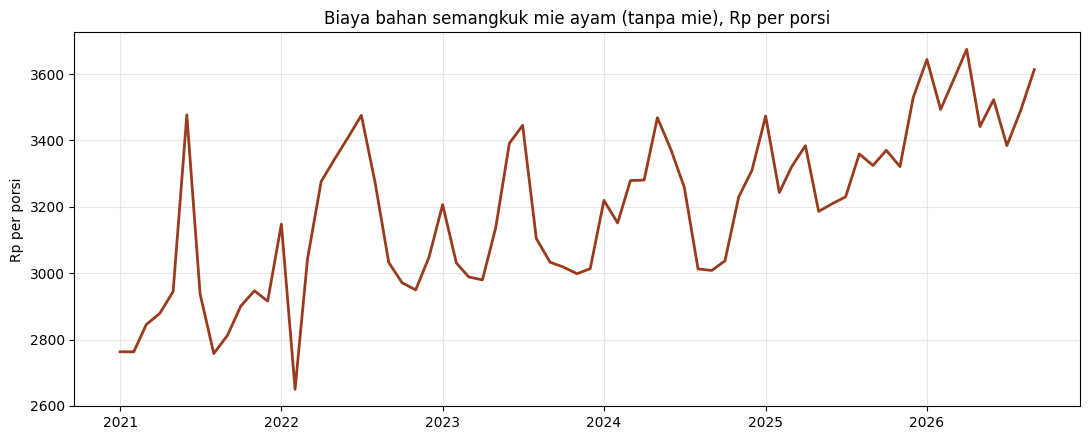

In [4]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(biaya.index, biaya['total_tanpa_mie'], color='#993C1D', linewidth=2)
ax.set_title('Biaya bahan semangkuk mie ayam (tanpa mie), Rp per porsi')
ax.set_ylabel('Rp per porsi'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [5]:
rp = lambda x: f"Rp {x:,.0f}".replace(',', '.')

awal = biaya['total_tanpa_mie'].iloc[0]
akhir = biaya['total_tanpa_mie'].iloc[-1]
puncak = biaya['total_tanpa_mie'].idxmax()
naik = 100 * (akhir / awal - 1)

print(f'Awal  ({biaya.index[0]:%Y-%m}) : {rp(awal)}')
print(f'Akhir ({biaya.index[-1]:%Y-%m}) : {rp(akhir)}')
print(f'Naik {naik:.1f}% sejak awal')
print(f'Puncak: {puncak:%Y-%m} di {rp(biaya.loc[puncak, "total_tanpa_mie"])}')

Awal  (2021-01) : Rp 2.763
Akhir (2026-09) : Rp 3.613
Naik 30.8% sejak awal
Puncak: 2026-04 di Rp 3.674


In [6]:
tahun = (biaya.index[-1] - biaya.index[0]).days / 365.25
porsi_ayam = 100 * biaya['ayam'].iloc[-1] / akhir
koma = lambda x: f"{x:.1f}".replace('.', ',')

display(Markdown(f"""
## Kesimpulan kecil

- Modal bahan semangkuk mie ayam (**tanpa mie**) naik dari **{rp(awal)}** ({biaya.index[0]:%b %Y}) jadi **{rp(akhir)}** ({biaya.index[-1]:%b %Y}). Artinya naik **{koma(naik)}%** dalam sekitar {koma(tahun)} tahun.
- Puncaknya ada di **{puncak:%B %Y}** dengan **{rp(biaya.loc[puncak, 'total_tanpa_mie'])}** per porsi.
- Dari empat bahan itu, **ayam** menyumbang sekitar **{koma(porsi_ayam)}%** dari total modal.
- Batasan: terigu (mie) belum masuk, 3 bulan bolong diisi interpolasi, Okt 2026 dibuang karena belum utuh, dan resep adalah asumsi.

**Next:** notebook 3, dari empat bahan itu, **siapa biang kerok** kenaikan modalnya?
"""))


## Kesimpulan kecil

- Modal bahan semangkuk mie ayam (**tanpa mie**) naik dari **Rp 2.763** (Jan 2021) jadi **Rp 3.613** (Sep 2026). Artinya naik **30,8%** dalam sekitar 5,7 tahun.
- Puncaknya ada di **April 2026** dengan **Rp 3.674** per porsi.
- Dari empat bahan itu, **ayam** menyumbang sekitar **70,7%** dari total modal.
- Batasan: terigu (mie) belum masuk, 3 bulan bolong diisi interpolasi, Okt 2026 dibuang karena belum utuh, dan resep adalah asumsi.

**Next:** notebook 3, dari empat bahan itu, **siapa biang kerok** kenaikan modalnya?
